In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
import warnings
warnings.filterwarnings('ignore')


In [3]:
# 加载数据
file_path = r'D:\PythonProjects\Airbnb-Performace\MergedEdinburgh\2024-10-18_listings.csv.gz'
listings = pd.read_csv(file_path, compression='gzip')
df = pd.read_csv(r'D:\PythonProjects\Airbnb-Performace\MergedEdinburgh\2024-10-18_listings.csv.gz')

# 提取需要清洗的列
cols_to_clean = [
    'number_of_reviews', 'price', 'reviews_per_month', 'room_type', 'accommodates', 
    'availability_30', 'bathrooms_text', 'bedrooms', 'beds', 'property_type', 
    'host_since', 'maximum_nights', 'minimum_nights', 'host_response_time', 
    'host_response_rate', 'host_acceptance_rate', 'host_listings_count', 
    'calculated_host_listings_count', 'host_is_superhost', 'host_identity_verified', 'latitude', 'longitude',
    'host_has_profile_pic', 'has_availability', 'instant_bookable', 'amenities','neighbourhood_cleansed'
]

df = df[cols_to_clean].copy()

In [4]:
# 第一步：基础清洗
# ==========================================
df = listings[cols_to_clean].copy()

# 1. 布尔值清洗
bool_cols = ['host_is_superhost', 'host_identity_verified', 'host_has_profile_pic', 'has_availability', 'instant_bookable']
for col in bool_cols:
    df[col] = df[col].map({'t': 1.0, 'f': 0.0})

# 2. 百分比清洗
for col in ['host_response_rate', 'host_acceptance_rate']:
    df[col] = df[col].astype(str).str.replace('%', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce') / 100.0

# 3. 提取浴室数字并计算天数
df['bathrooms'] = df['bathrooms_text'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)
scrape_date = pd.to_datetime('2024-10-18')
df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
df['host_days'] = (scrape_date - df['host_since']).dt.days

# 4. 分类变量映射
df['room_type_code'] = df['room_type'].map({'Private room': 1, 'Entire home/apt': 2, 'Shared room': 3, 'Hotel room': 4})
df['host_response_time_code'] = df['host_response_time'].str.lower().map(
    {'within an hour': 1, 'within a few hours': 2, 'within a day': 3, 'a few days or more': 4}
)

# 5. Amenities 处理
df['amenities'] = df['amenities'].fillna('')
cleaned_amenities = df['amenities'].astype(str).str.replace(r'[{}"\'\[\]]', '', regex=True).str.lower()
df['amenity_tv'] = cleaned_amenities.str.contains('tv').astype(float)
df['amenity_air_conditioning'] = cleaned_amenities.str.contains('air conditioning|ac').astype(float)
df['amenity_coffee'] = cleaned_amenities.str.contains('coffee').astype(float)
df['amenity_luggage'] = cleaned_amenities.str.contains('luggage').astype(float)

# 6. 丢弃原始冗余列
cols_to_drop = ['bathrooms_text', 'room_type', 'host_response_time', 'property_type', 'host_since', 'amenities']
df = df.drop(columns=cols_to_drop)

In [ ]:
# 第二步：拆分数据集
# 注意：此时保留了 latitude 和 longitude，用于后面的 Price 插补
y = df['price'].copy()
X = df.drop(columns=['price']).copy()

# 拆分 (此时 X_train 和 y_train 里面都包含 NaN)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"切分完成! 训练集: {X_train.shape}, 测试集: {X_test.shape}")

# ==========================================
# Impute other control variables
# ==========================================
# Categorical variables
categorical_cols = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 
                    'has_availability', 'instant_bookable', 'room_type_code', 'host_response_time_code']

# Spatial identifiers
spatial_cols = ['neighbourhood_cleansed', 'latitude', 'longitude']

# Continuous/discrete variables
continuous_cols = [col for col in X_train.columns if col not in categorical_cols and col not in spatial_cols]

# 1. Categorical variables: Imputed using the mode
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols]  = cat_imputer.transform(X_test[categorical_cols])

# 2. Continuous/discrete variables: Iterative imputation with Bayesian Ridge
iter_imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=25, random_state=42, min_value=0)
X_train[continuous_cols] = iter_imputer.fit_transform(X_train[continuous_cols])
X_test[continuous_cols]  = iter_imputer.transform(X_test[continuous_cols])

# 3. Count discretization (rounded to the nearest integer)
discrete_cols = ['bedrooms', 'bathrooms', 'beds', 'accommodates']
for col in discrete_cols:
    if col in X_train.columns:
        X_train[col] = np.round(X_train[col])
        X_test[col]  = np.round(X_test[col])

print(f"X_train 剩余缺失: {X_train.isnull().sum().max()}")

切分完成! 训练集: (4503, 28), 测试集: (1126, 28)
X_train 剩余缺失: 0


In [ ]:
# ==========================================
# 拼合完整数据集 & 清洗 Price 字符串
# ==========================================
# 1. 拼合训练集和测试集
train_full = pd.concat([X_train, y_train], axis=1)
train_full['dataset_split'] = 'train' 

test_full = pd.concat([X_test, y_test], axis=1)
test_full['dataset_split'] = 'test'

# 2. 上下合并为最终的完整全量数据集
df_imputed_final = pd.concat([train_full, test_full])

# 把文本价格洗成纯数字
df_imputed_final['price'] = pd.to_numeric(
    df_imputed_final['price'].astype(str).str.replace(r'[\$,]', '', regex=True), 
    errors='coerce'
)

In [8]:
# 1. 严格防泄露：仅提取训练集数据来计算中位数
train_data = df_imputed_final[df_imputed_final['dataset_split'] == 'train']
neighborhood_medians = train_data.groupby('neighbourhood_cleansed')['price'].median()
global_median = train_data['price'].median()

# 2. 找出全集中所有 Price 缺失的行
missing_mask = df_imputed_final['price'].isna()

if missing_mask.sum() > 0:
    # 用训练集算出的中位数，去映射并填补全集里的缺失值
    imputed_prices = df_imputed_final.loc[missing_mask, 'neighbourhood_cleansed'].map(neighborhood_medians).fillna(global_median)
    df_imputed_final.loc[missing_mask, 'price'] = imputed_prices

print(f"全集 Price 剩余缺失量: {df_imputed_final['price'].isna().sum()}")

全集 Price 剩余缺失量: 0


In [9]:
# ==========================================
# 剔除极值、取对数 & 导出
# ==========================================
# 1. 剔除 Top 1% 异常天价房源
q99_price = df_imputed_final['price'].quantile(0.99)
df_imputed_final = df_imputed_final[df_imputed_final['price'] <= q99_price]

# 2. 过滤掉价格小于等于 0 的异常值，防止 log 报错
df_imputed_final = df_imputed_final[df_imputed_final['price'] > 0]

# 3. 生成新的 log_price 列
df_imputed_final['log_price'] = np.log(df_imputed_final['price'])

# 4. 导出为 CSV 文件
output_path = r'D:\PythonProjects\Airbnb-Performace\MergedEdinburgh\2024-10-18_listings_priceCLEANED_Neighborhood.csv'
df_imputed_final.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"最终输出的数据表大小: {df_imputed_final.shape}")


最终输出的数据表大小: (5591, 31)


=== 最终清洗并插补后的数据全貌 ===
1. 总有效样本量: 5591 个房源
2. 价格统计摘要 (Price Summary):
count    5591.00
mean      174.64
std       130.92
min        18.00
25%       100.00
50%       145.00
75%       196.00
max      1000.00
Name: price, dtype: float64


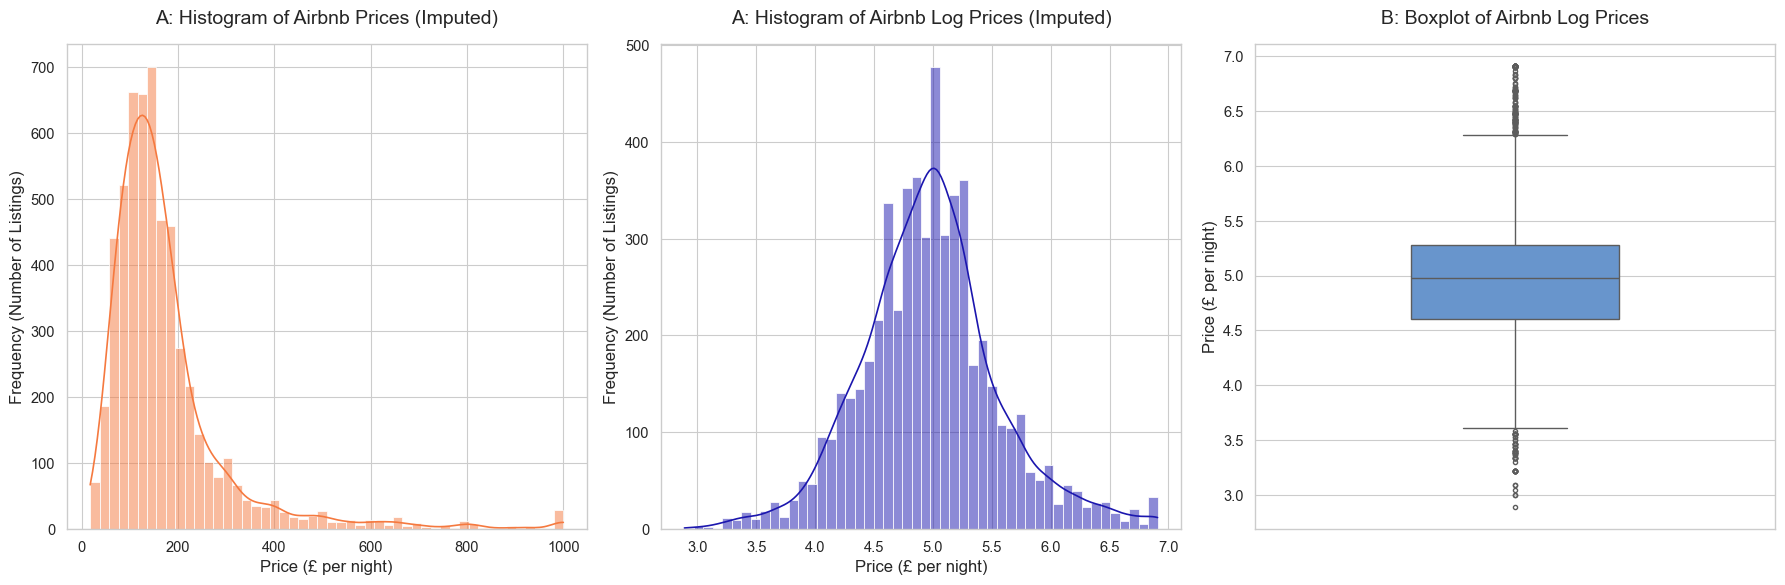

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置学术风格的绘图主题
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# ==========================================
# 1. 打印全集数据的核心统计量 (可以直接抄进论文表格)
# ==========================================
total_samples = len(df_imputed_final)
print(f"=== 最终清洗并插补后的数据全貌 ===")
print(f"1. 总有效样本量: {total_samples} 个房源")
print(f"2. 价格统计摘要 (Price Summary):")
print(df_imputed_final['price'].describe().round(2))

# ==========================================
# 2. 价格分布可视化 (双子图: 直方图 + 箱线图)
# ==========================================
# 创建一个 1行2列 的画布，尺寸 14x6
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- 图 1，2：带核密度估计 (KDE) 的直方图 ---
sns.histplot(
    df_imputed_final['price'], 
    bins=50,          # 分 50 个柱子
    kde=True,         # 画出平滑的概率密度曲线
    color="#f5793f",  # 学术蓝
    edgecolor='white',
    ax=axes[0]
)
axes[0].set_title('A: Histogram of Airbnb Prices (Imputed)', fontsize=14, pad=15)
axes[0].set_xlabel('Price (£ per night)', fontsize=12)
axes[0].set_ylabel('Frequency (Number of Listings)', fontsize=12)

sns.histplot(
    df_imputed_final['log_price'], 
    bins=50,          # 分 50 个柱子
    kde=True,         # 画出平滑的概率密度曲线
    color="#1b16ae",  # 学术蓝
    edgecolor='white',
    ax=axes[1]
)
axes[1].set_title('A: Histogram of Airbnb Log Prices (Imputed)', fontsize=14, pad=15)
axes[1].set_xlabel('Price (£ per night)', fontsize=12)
axes[1].set_ylabel('Frequency (Number of Listings)', fontsize=12)

# --- 图 3：箱线图 (Boxplot) 看集中度和尾部 ---
sns.boxplot(
    y=df_imputed_final['log_price'], 
    color="#5793dd", 
    width=0.4,
    fliersize=3,      # 离群点大小
    ax=axes[2]
)
axes[2].set_title('B: Boxplot of Airbnb Log Prices', fontsize=14, pad=15)
axes[2].set_ylabel('Price (£ per night)', fontsize=12)

# 调整布局并展示
plt.tight_layout()

# 图保存到本地用于论文
plt.savefig(r'D:\PythonProjects\Airbnb-Performace\price_distribution.png', dpi=300, bbox_inches='tight')

plt.show()